### Etap 3

Ostatnia część projektu związana jest z opracowaniem modelu regresji (2,5 pkt.), poprzez
zastosowanie poznanych na wykładzie i ćwiczeniach laboratoryjnych metodach doboru cech
(2,5 pkt.) i regularyzacji (2,5 pkt.) oraz opracowanie raportu opisującego przeprowadzone prace,
jak i wyciągnięte wnioski z otrzymanych wyników/zależności (2,5 pkt.).

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Wczytanie zbioru danych:

In [2]:
df = pd.read_csv('data/df_merged_without_outliers.csv')

### Transformacje zmiennych, aby ich rozkład był bardziej podobny do normalnego

Lista atrybutów o rozkładzie prawoskośnym:

In [3]:
right_skewed = np.array(['TotalPop', 'Hispanic', 'Black', 'Native', 'Asian', 'Pacific', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Average_House_Price'], dtype=object)

Lista atrybutów o rozkładzie lewoskośnym:

In [4]:
left_skewed = np.array(['White', 'Drive', 'PrivateWork'], dtype=object)

Dla wcześniej wybranych odpowiednich podstaw logarytmy z przedziału [1.5, 2.0, 2.5, ..., 10.0] przy użyciu testu statystycznego Shapiro-Wilk (skrypt right_skewed_to_normal.py) dokonujemy transformacji danych. Jeżeli logarytmowanie nie pomoże, histogram dla logarytmowanych wartości nie będzie wyświetlany.

**Nie mogliśmy zamieścić wyboru, ponieważ dla różnych wersji i maszyn biblioteki scipy.stats działała ona inaczej

<Figure size 1000x2500 with 0 Axes>

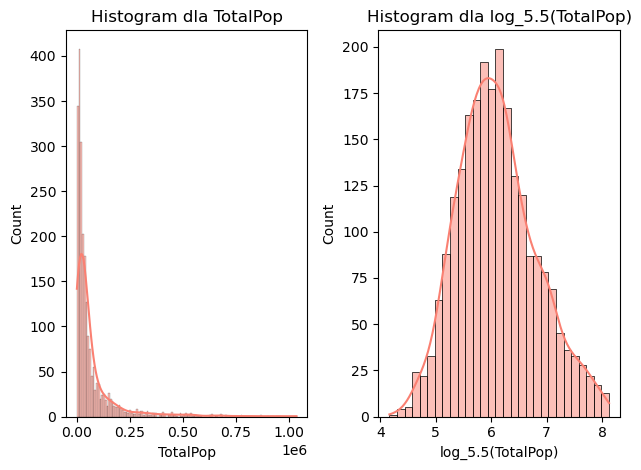

<Figure size 1000x2500 with 0 Axes>

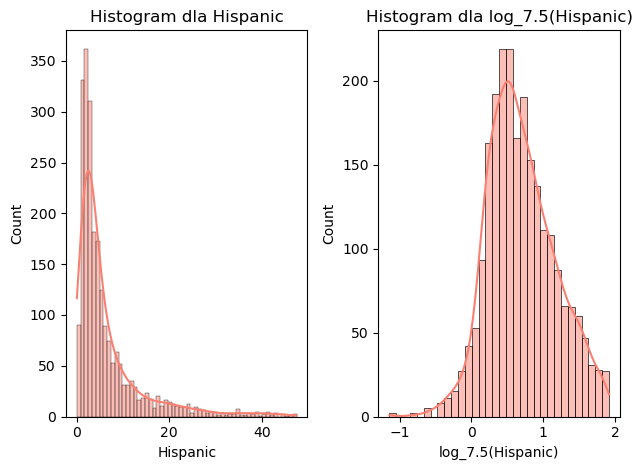

<Figure size 1000x2500 with 0 Axes>

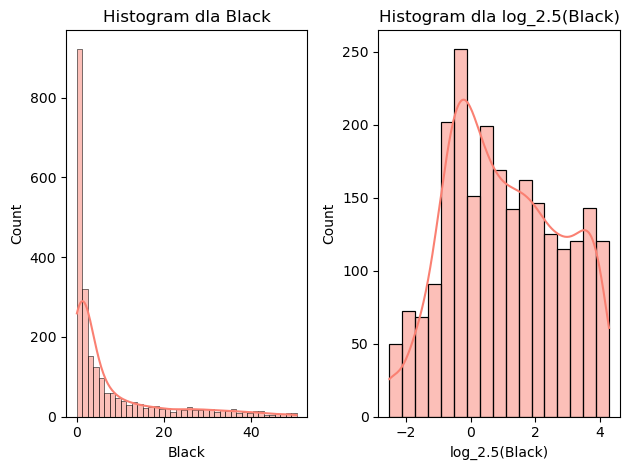

<Figure size 1000x2500 with 0 Axes>

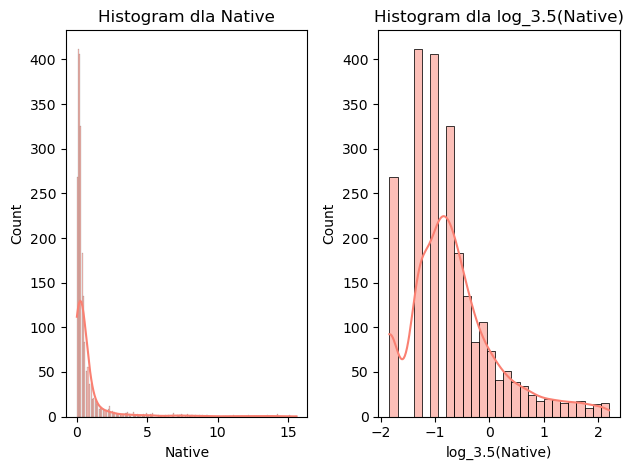

<Figure size 1000x2500 with 0 Axes>

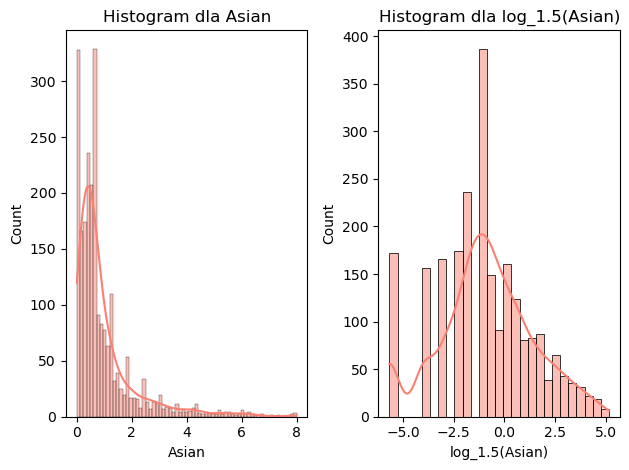

<Figure size 1000x2500 with 0 Axes>

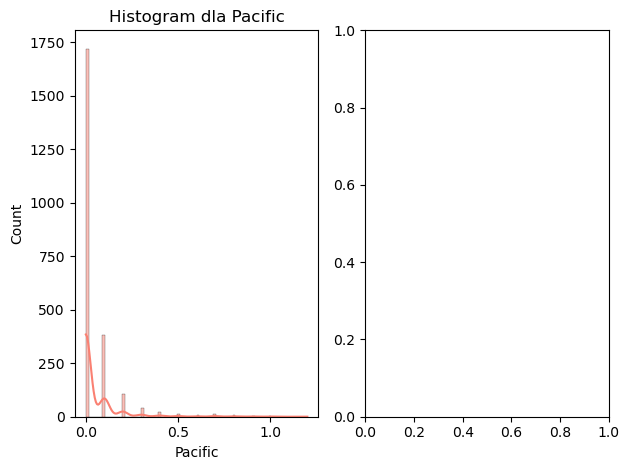

<Figure size 1000x2500 with 0 Axes>

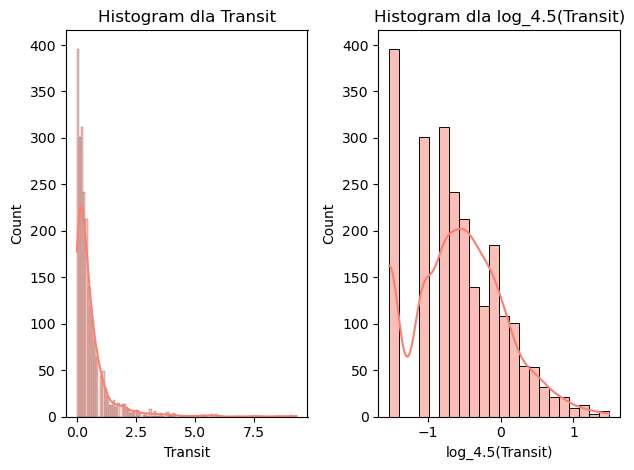

<Figure size 1000x2500 with 0 Axes>

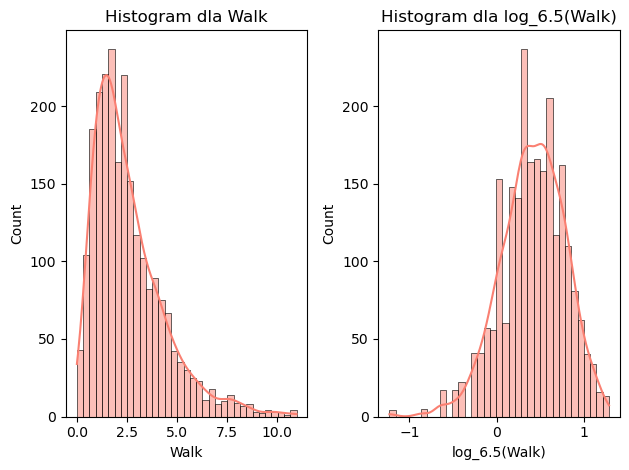

<Figure size 1000x2500 with 0 Axes>

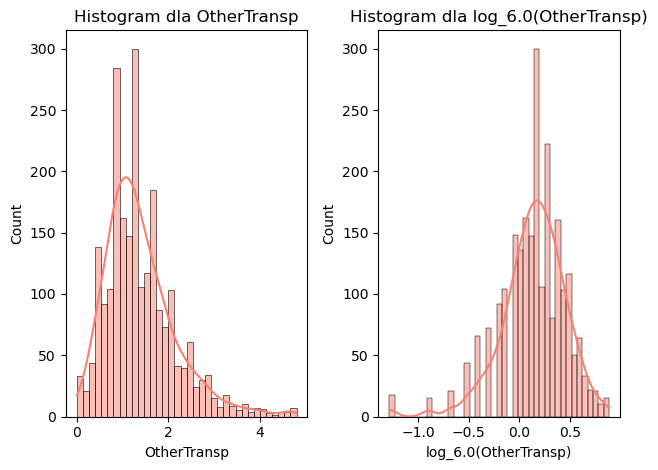

<Figure size 1000x2500 with 0 Axes>

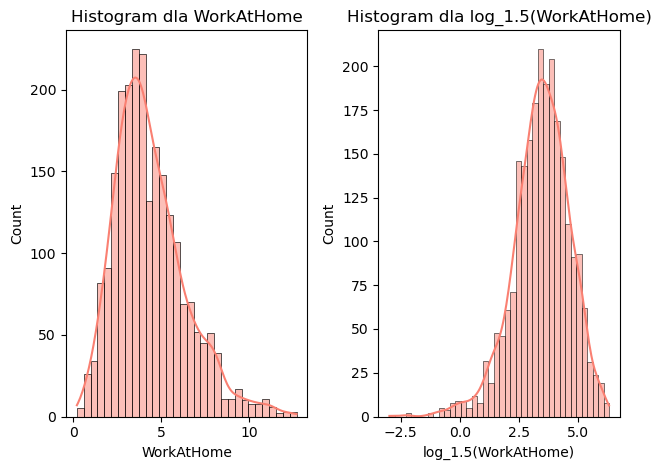

<Figure size 1000x2500 with 0 Axes>

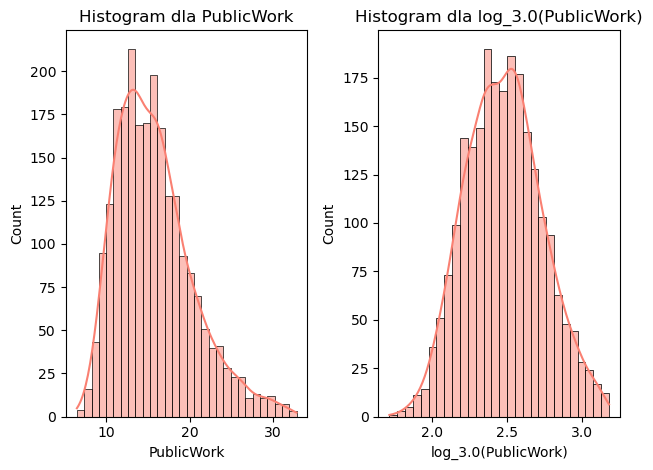

<Figure size 1000x2500 with 0 Axes>

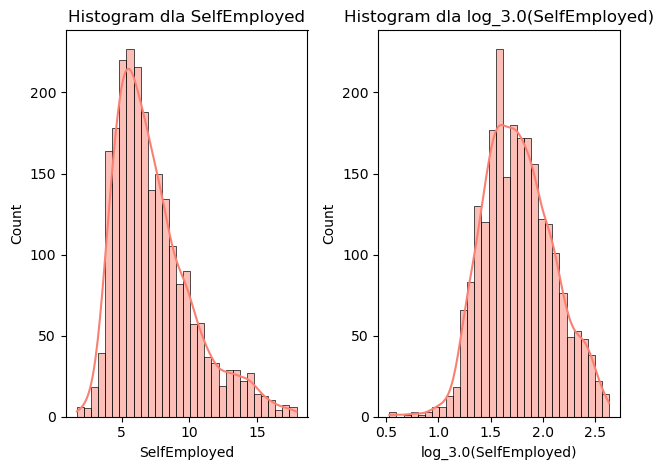

<Figure size 1000x2500 with 0 Axes>

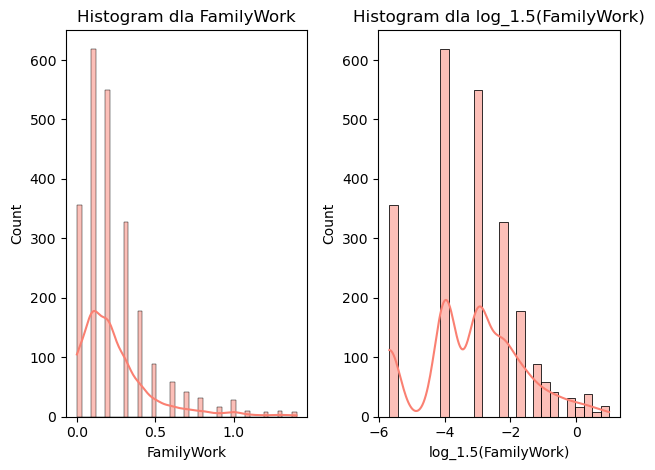

<Figure size 1000x2500 with 0 Axes>

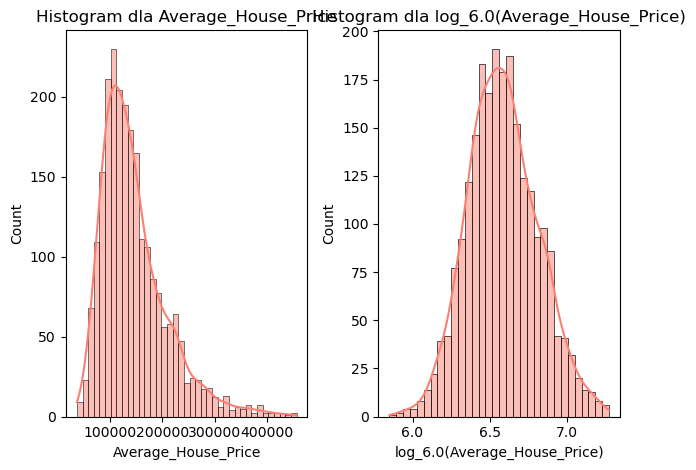

In [5]:
from scripts.right_skewed import to_normal

for attr in right_skewed:
    df = to_normal(df, attr)

Dla wszystkich atrybutów poza `Pacific` przekształcenie logarytmiczne pomogło uzyskać rozkład bardziej zbliżony do normalnego.

Dla wcześniej wybranych odpowiednich wykładników z przedziału [1.5, 2.0, 2.5, ..., 10.0] przy użyciu testu statystycznego Shapiro-Wilk (skrypt left_skewed_to_normal.py) dokonujemy transformacji danych. Jeżeli logarytmowanie nie pomoże, histogram dla logarytmowanych wartości nie będzie wyświetlany.

**Nie mogliśmy zamieścić wyboru, ponieważ dla różnych wersji i maszyn biblioteki scipy.stats działała ona inaczej

<Figure size 1000x2500 with 0 Axes>

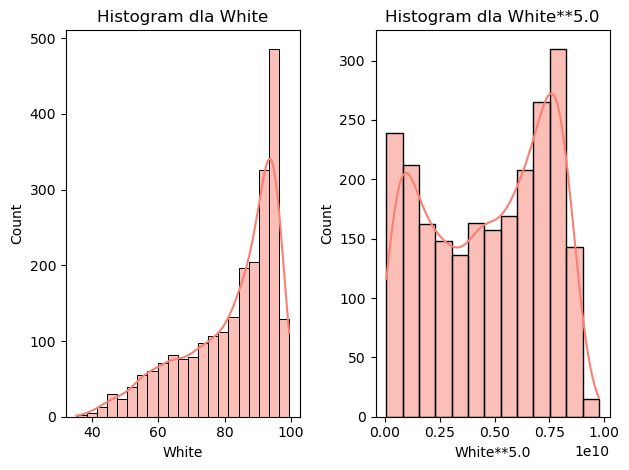

<Figure size 1000x2500 with 0 Axes>

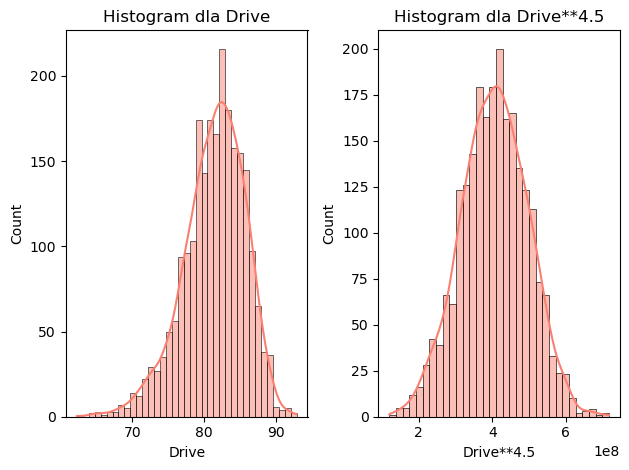

<Figure size 1000x2500 with 0 Axes>

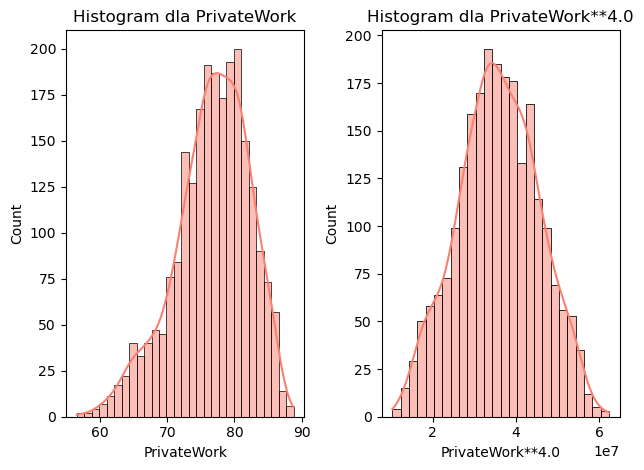

In [6]:
from scripts.left_skewed import to_normal

for attr in left_skewed:
    df = to_normal(df, attr)

Dla wszystkich atrybutów z rozkładem prawoskośnym potęgowanie pomogło uzyskać rozkład bardziej normalny, jednakże dla atrybutu `White` zmieniło rozkład z jednomodalnego na dwumodalny.

### Macierz korelacji po dodaniu transformowanych cech

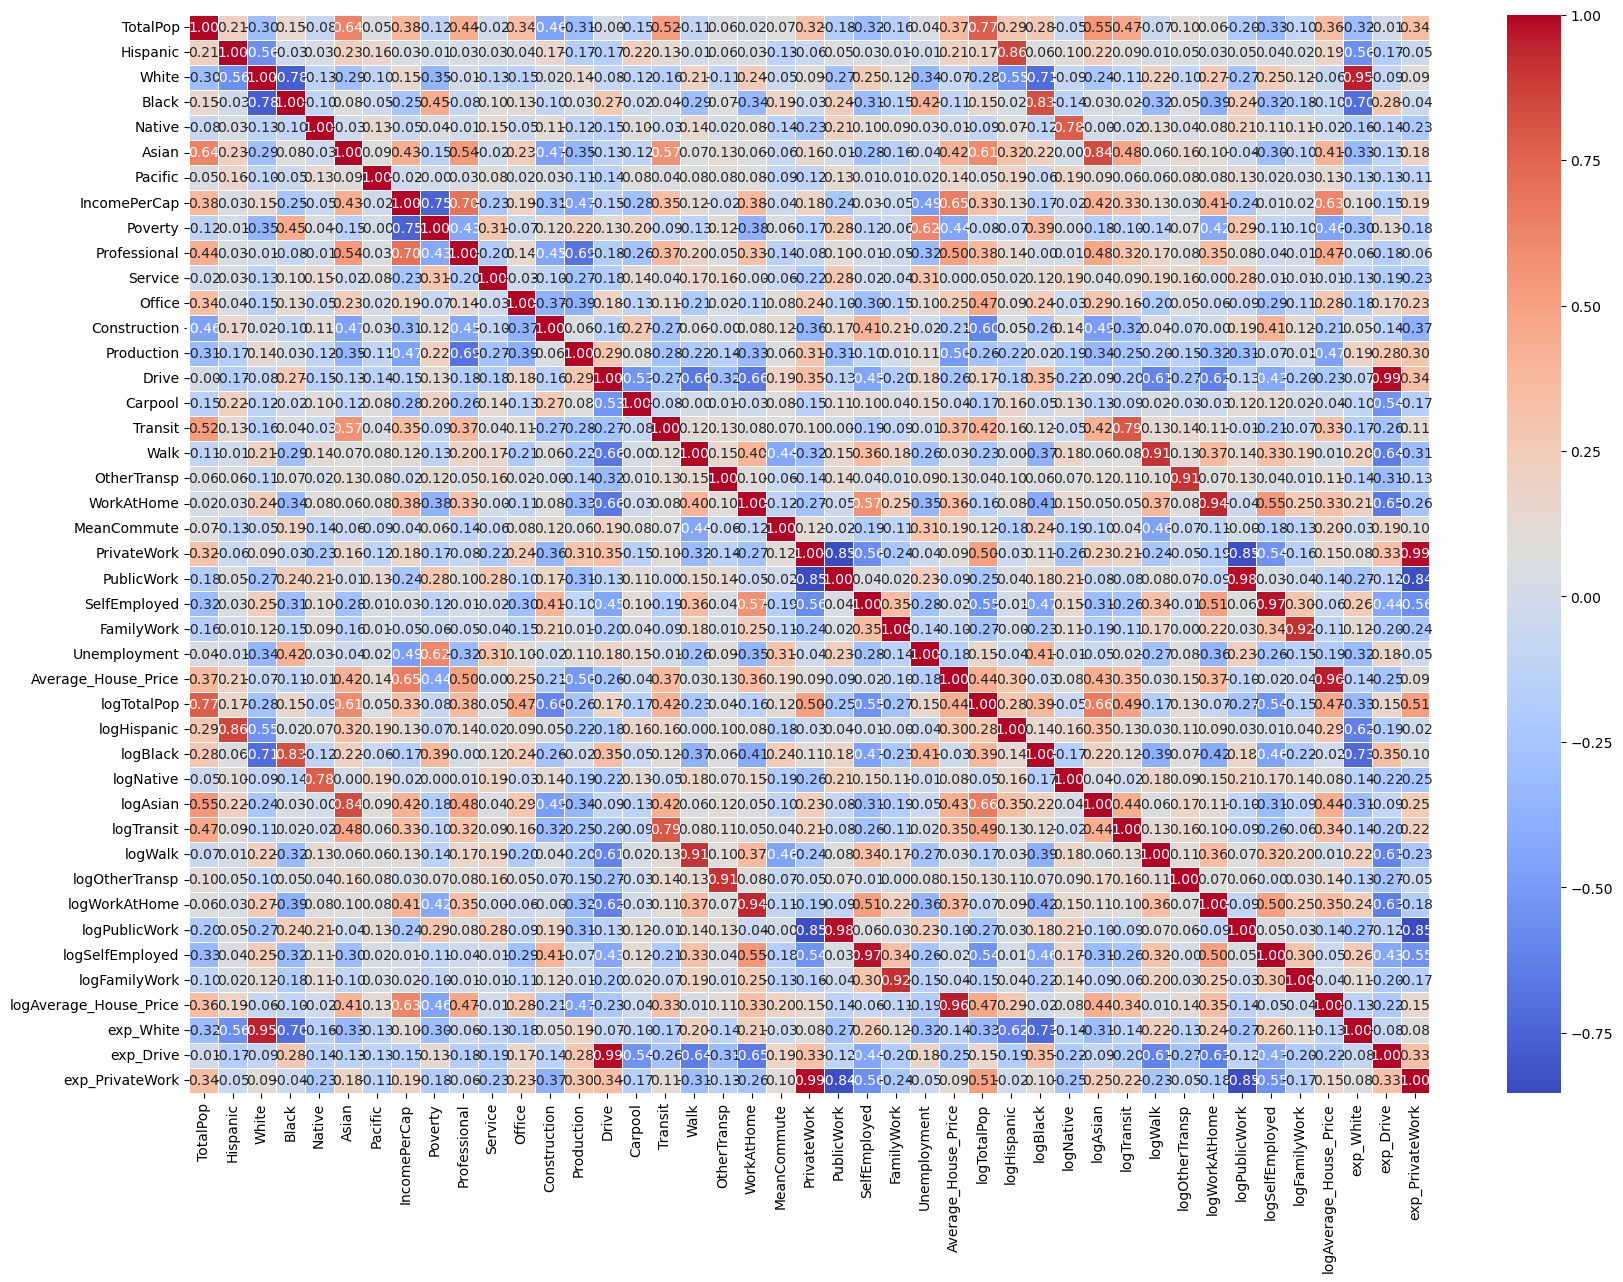

In [7]:
correlation_matrix = df.iloc[:,3:].corr()

plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)

Każda z transformowanych cech ma wysoką korelację z cechą oryginalną. Usuwamy więc ze zbioru wszystkie cechy, których transformacje dodaliśmy do zbioru.

In [8]:
features = df.columns.tolist()[3:]
left_skewed_list = left_skewed.tolist()
right_skewed_list = right_skewed.tolist()
filtered_features = [attr for attr in features if attr not in left_skewed_list]
filtered_features2 = [attr for attr in filtered_features if attr not in right_skewed_list]
df = df[df.columns.tolist()[:3] + filtered_features2]
display(df.columns.tolist())

['Unnamed: 0',
 'State',
 'County',
 'IncomePerCap',
 'Poverty',
 'Professional',
 'Service',
 'Office',
 'Construction',
 'Production',
 'Carpool',
 'MeanCommute',
 'Unemployment',
 'logTotalPop',
 'logHispanic',
 'logBlack',
 'logNative',
 'logAsian',
 'logTransit',
 'logWalk',
 'logOtherTransp',
 'logWorkAtHome',
 'logPublicWork',
 'logSelfEmployed',
 'logFamilyWork',
 'logAverage_House_Price',
 'exp_White',
 'exp_Drive',
 'exp_PrivateWork']

### Macierz korelacji po usunięciu elementów które zostały przetransformowane

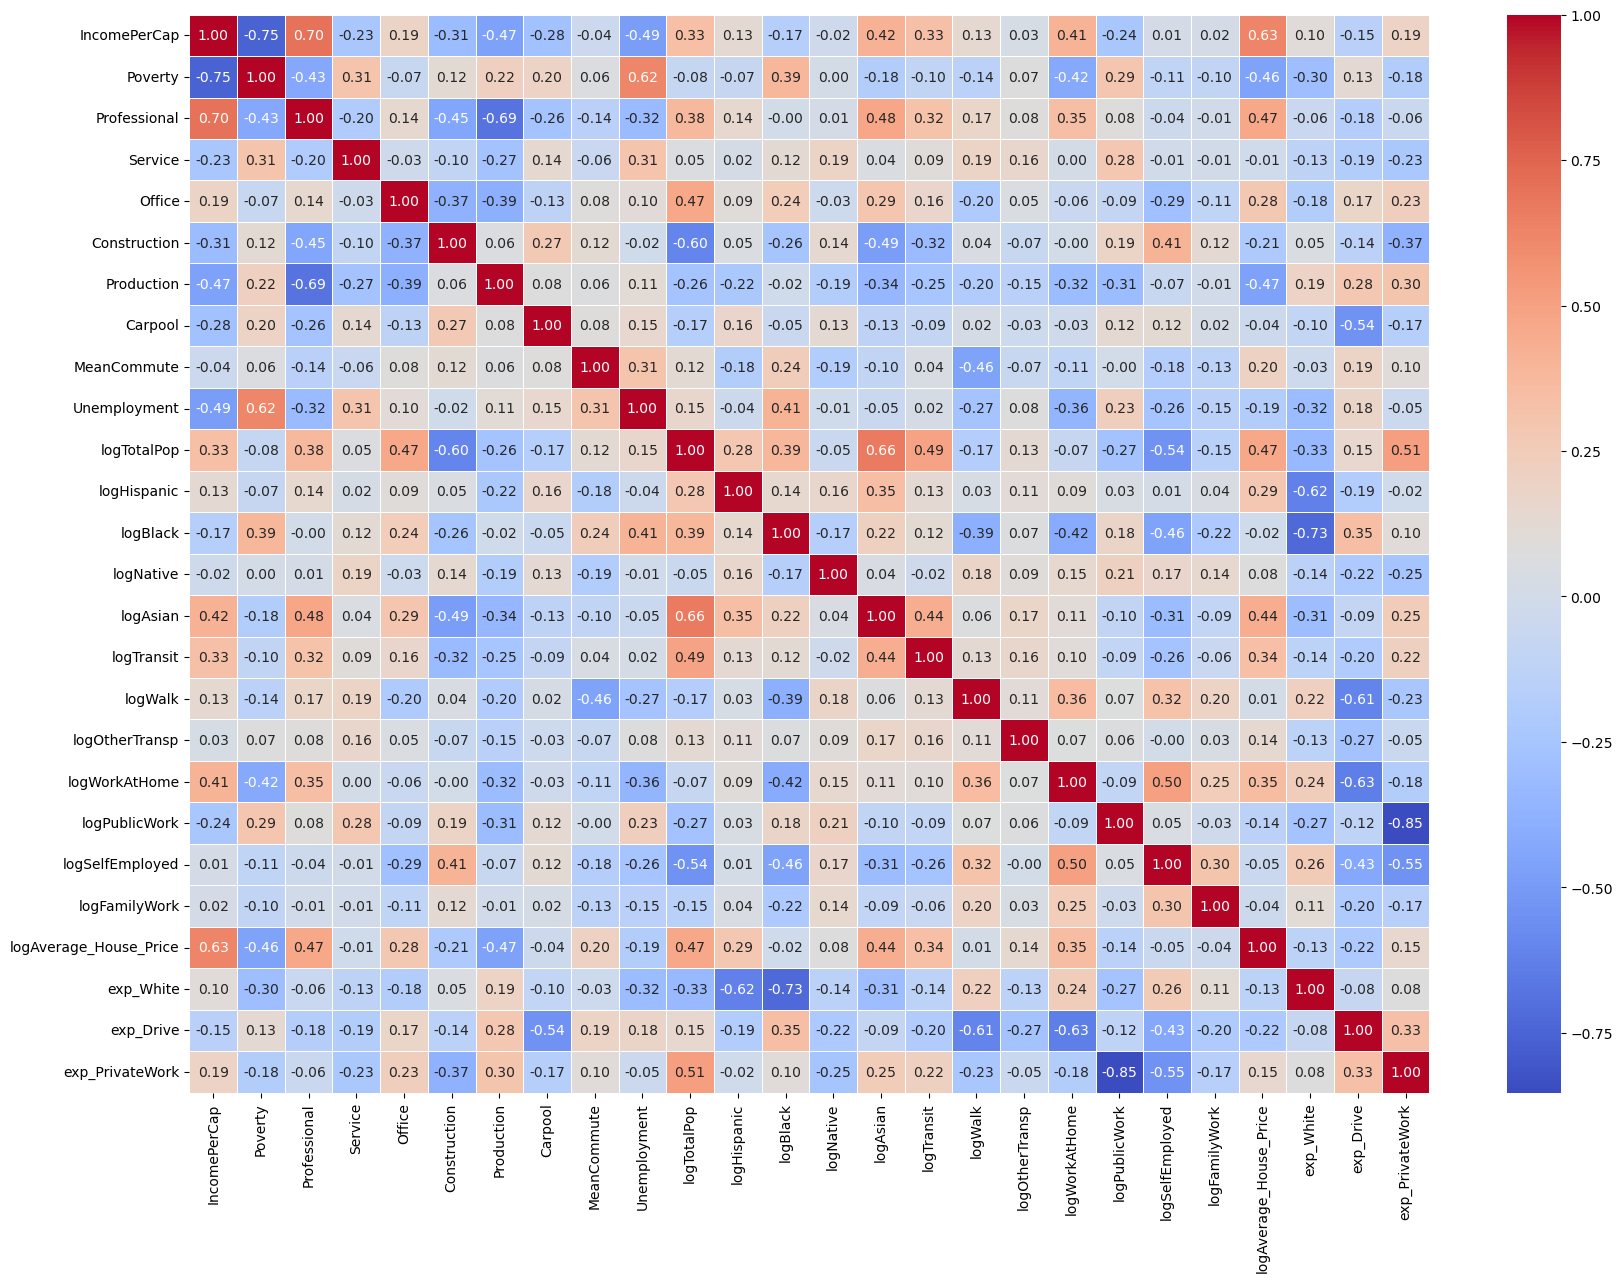

In [9]:
correlation_matrix = df.iloc[:,3:].corr()

plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)

Przetransformowane atrybuty `logPublicWork` i `exp_PrivateWork` mają wysoką korelację (-0,85), więc należy jeden z nich usunąć. Usuniemy ten z mniejszą korelacją z atrybutem decyzyjnym, czyli `exp_PrivateWork`.

Podobnie sytuacja wygląda z atrybutami:
 - `logBlack` i `exp_White` (korelacja 0,73), dlatego usuniemy `exp_White`.
 - `Production` i `Professional` (korelacja 0,69), dlatego usuniemy `Production`


In [10]:
df.drop(columns = ['exp_PrivateWork', 'exp_White', 'Production'], inplace=True)

In [11]:
df

,Unnamed: 0,State,County,IncomePerCap,Poverty,Professional,Service,Office,Construction,Carpool,...,logAsian,logTransit,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_Drive
0,0,Alabama,Autauga County,27824,13.7,35.3,18.0,23.2,8.1,9.6,...,0.000000,-1.070050,-0.190552,0.187789,2.356581,2.740385,1.584241,-3.969362,6.707548,5.099342e+08
1,1,Alabama,Baldwin County,29364,11.8,35.7,18.2,25.6,9.7,7.6,...,-0.550340,-1.070050,-0.056288,0.101756,4.292518,2.334718,1.689675,-3.969362,6.866816,4.761912e+08
2,2,Alabama,Barbour County,17561,27.2,25.0,16.8,22.6,11.5,11.1,...,-0.879669,-0.609205,0.444977,0.328050,0.829843,2.689675,1.717685,-2.259851,6.440511,4.442108e+08
3,3,Alabama,Bibb County,20911,15.2,24.4,17.6,19.7,15.9,9.5,...,-5.678874,-0.148359,-0.489523,0.328050,1.159172,2.605288,1.689675,-2.259851,6.597469,5.206819e+08
4,4,Alabama,Blount County,22021,15.6,28.5,12.9,23.3,15.8,10.2,...,-3.969362,-1.070050,-0.370310,-0.386853,1.944575,2.261860,1.284336,-3.969362,6.651177,5.316049e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,2887,Wyoming,Sheridan County,31643,6.8,41.1,17.5,20.2,12.1,10.9,...,-0.550340,-0.800473,0.653795,-0.124539,4.292518,2.821826,1.689675,-2.969362,6.962623,3.561657e+08
2323,2889,Wyoming,Sweetwater County,31700,12.0,27.7,16.1,20.0,20.8,14.4,...,-0.879669,0.660373,0.568816,0.187789,1.159172,2.625859,1.238814,-5.678874,6.854041,3.194315e+08
2324,2891,Wyoming,Uinta County,27115,14.9,30.4,19.4,18.1,16.1,14.9,...,-3.969362,0.813639,0.097404,0.187789,1.829843,2.796886,1.731373,-1.709511,6.773738,3.175833e+08
2325,2892,Wyoming,Washakie County,27345,12.8,32.1,16.3,17.6,18.8,10.2,...,-3.969362,-1.530895,1.039592,0.187789,3.709511,2.817716,1.915265,-2.969362,6.712298,3.139119e+08


In [12]:
df.columns.to_list()

['Unnamed: 0',
 'State',
 'County',
 'IncomePerCap',
 'Poverty',
 'Professional',
 'Service',
 'Office',
 'Construction',
 'Carpool',
 'MeanCommute',
 'Unemployment',
 'logTotalPop',
 'logHispanic',
 'logBlack',
 'logNative',
 'logAsian',
 'logTransit',
 'logWalk',
 'logOtherTransp',
 'logWorkAtHome',
 'logPublicWork',
 'logSelfEmployed',
 'logFamilyWork',
 'logAverage_House_Price',
 'exp_Drive']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

### Dobór cech dla modelu regresji liniowej przy użyciu metody zachłannej

Do ewaluacji użyliśmy walidacji krzyżowej zbioru podzielonego na 5 części, ponieważ zawiera on dużo danych (>1000 rekordów).

In [14]:
from scripts.greedy_features import find_best_features

features = df.columns[3:]
find_best_features(df[features], 'IncomePerCap')

['Poverty'] 10218987.616236247

['Poverty', 'Professional'] 6181474.142286185

['Poverty', 'Professional', 'logAverage_House_Price'] 5350340.8122964315

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 5067159.469261656

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 4951472.480056727

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 4866808.40423652

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment'] 4860577.101881792

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork'] 4855520.896381021

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork', 'logSelfEmployed'] 4848662.475693612

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool

Sprawdzamy, czy skalowanie lub standaryzacja danych wpływa na wynik. 

In [15]:
from sklearn.preprocessing import StandardScaler

std_dev_target = df['IncomePerCap'].std()

df_stantard = df[:]
scaler = StandardScaler()
columns_to_scale = df.columns[4:]
df_stantard[columns_to_scale] = scaler.fit_transform(df_stantard[columns_to_scale])

find_best_features(df_stantard[features], 'IncomePerCap', is_standarized=True, std_dev=std_dev_target)

['Poverty'] 10218987.616236249

['Poverty', 'Professional'] 6181474.14228619

['Poverty', 'Professional', 'logAverage_House_Price'] 5350340.812296444

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 5067159.469261657

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 4951472.480056728

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 4866808.404236522

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment'] 4860577.101881796

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork'] 4855520.896381023

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork', 'logSelfEmployed'] 4848662.475693615

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'

In [16]:
from sklearn.preprocessing import MinMaxScaler

min_target = df['IncomePerCap'].min()
max_target = df['IncomePerCap'].max()
range_target = max_target - min_target

df_normalized = df[:]
scaler = MinMaxScaler()
columns_to_scale = df.columns[4:]
df_normalized[columns_to_scale] = scaler.fit_transform(df_normalized[columns_to_scale])

find_best_features(df_normalized[features], 'IncomePerCap', is_normalized=True, range_minmax=range_target)

['Poverty'] 10218987.61623624

['Poverty', 'Professional'] 6181474.142286186

['Poverty', 'Professional', 'logAverage_House_Price'] 5350340.812296445

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 5067159.4692616565

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 4951472.480056726

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 4866808.40423652

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment'] 4860577.101881793

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork'] 4855520.896381022

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork', 'logSelfEmployed'] 4848662.475693615

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'

Ani dodatkowa standaryzacja, ani normalizacja nie mają praktycznie żadnego wpływu na błąd modelu.

In [17]:
# Cechy, dla których błąd był najmniejszy:
best_features = ['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork', 'logSelfEmployed', 'logAsian', 'logBlack', 'logOtherTransp', 'Office', 'logTotalPop']

### Model regresji liniowej

In [18]:
def linear_regression(x_train, x_test, y_train, y_test):
    regresor = LinearRegression()
    regresor.fit(x_train, y_train)
    y_pred_train = regresor.predict(x_train)
    y_pred_test = regresor.predict(x_test)
    e_train= mean_squared_error(y_train, y_pred_train)
    e_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle("Regresja Wieloraka")

    axs[0].scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
    axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
    axs[0].set_xlabel("Rzeczywiste wartości")
    axs[0].set_ylabel("Przewidywane wartości")
    axs[0].set_title("Rzeczywiste vs Przewidywane (Train)")
    axs[0].legend()

    axs[1].scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
    axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
    axs[1].set_xlabel("Rzeczywiste wartości")
    axs[1].set_ylabel("Przewidywane wartości")
    axs[1].set_title("Rzeczywiste vs Przewidywane (Test)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    return e_train, e_test, r2_train, r2_test, regresor.coef_


Dla cech początkowych:

In [19]:
X1 = df[features].iloc[:,1:]
X1

,Poverty,Professional,Service,Office,Construction,Carpool,MeanCommute,Unemployment,logTotalPop,logHispanic,...,logAsian,logTransit,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_Drive
0,13.7,35.3,18.0,23.2,8.1,9.6,25.8,5.2,6.403152,0.511002,...,0.000000,-1.070050,-0.190552,0.187789,2.356581,2.740385,1.584241,-3.969362,6.707548,5.099342e+08
1,11.8,35.7,18.2,25.6,9.7,7.6,27.0,5.5,7.169821,0.746476,...,-0.550340,-1.070050,-0.056288,0.101756,4.292518,2.334718,1.689675,-3.969362,6.866816,4.761912e+08
2,27.2,25.0,16.8,22.6,11.5,11.1,23.4,12.4,5.967797,0.723913,...,-0.879669,-0.609205,0.444977,0.328050,0.829843,2.689675,1.717685,-2.259851,6.440511,4.442108e+08
3,15.2,24.4,17.6,19.7,15.9,9.5,30.0,8.2,5.880555,0.454757,...,-5.678874,-0.148359,-0.489523,0.328050,1.159172,2.605288,1.689675,-2.259851,6.597469,5.206819e+08
4,15.6,28.5,12.9,23.3,15.8,10.2,35.0,4.9,6.430544,1.095971,...,-3.969362,-1.070050,-0.370310,-0.386853,1.944575,2.261860,1.284336,-3.969362,6.651177,5.316049e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,6.8,41.1,17.5,20.2,12.1,10.9,16.0,3.1,6.046515,0.723913,...,-0.550340,-0.800473,0.653795,-0.124539,4.292518,2.821826,1.689675,-2.969362,6.962623,3.561657e+08
2323,12.0,27.7,16.1,20.0,20.8,14.4,20.5,5.2,6.278859,1.379133,...,-0.879669,0.660373,0.568816,0.187789,1.159172,2.625859,1.238814,-5.678874,6.854041,3.194315e+08
2324,14.9,30.4,19.4,18.1,16.1,14.9,19.9,6.4,5.831205,1.101395,...,-3.969362,0.813639,0.097404,0.187789,1.829843,2.796886,1.731373,-1.709511,6.773738,3.175833e+08
2325,12.8,32.1,16.3,17.6,18.8,10.2,14.3,6.1,5.290197,1.320292,...,-3.969362,-1.530895,1.039592,0.187789,3.709511,2.817716,1.915265,-2.969362,6.712298,3.139119e+08


/tmp/ipykernel_84168/2690550006.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
/tmp/ipykernel_84168/2690550006.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


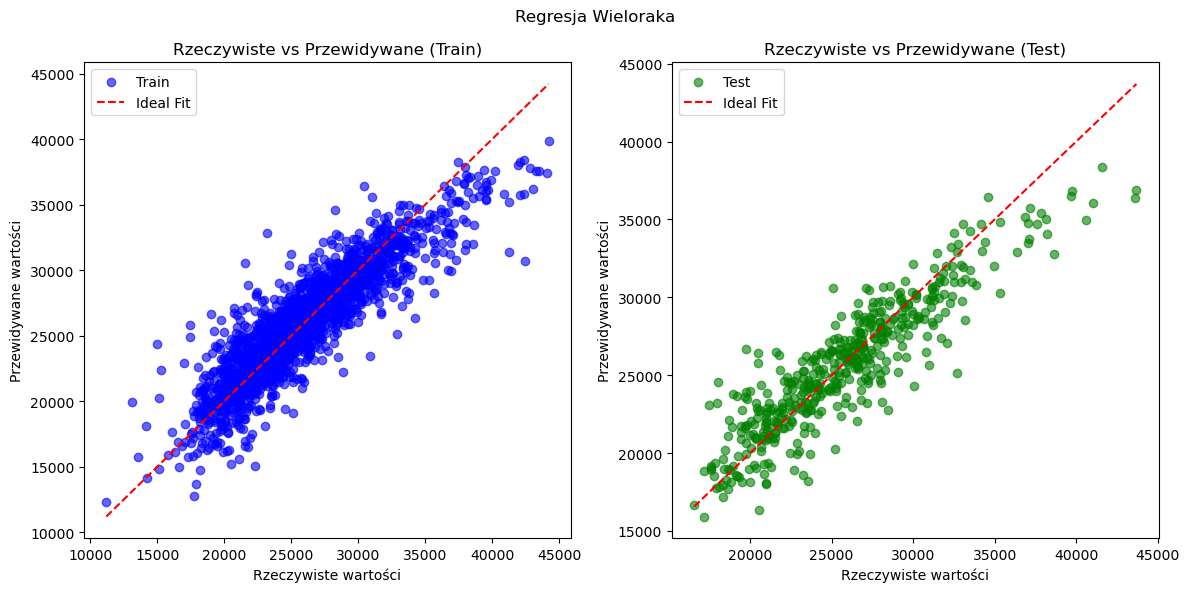

Mean Squared Error for train: 4644371.217234767
Mean Squared Error for test: 4505178.806332274
R2 Score for train: 0.8005665686014655
R2 Score for test: 0.8112116996918962
Coefficients: [-13091.96156466  12186.83453418   1322.80412987   1227.79088007
    943.87709594  -3890.50937737    -16.09107999  -1179.36541323
   -376.77202122   -968.68163407   1033.96744765   -236.05406499
    992.73446052   1473.82530099  -1316.34800697   -842.12678725
  -2315.52611562  -3567.75843277   1542.02723121   -425.56325792
   5644.11764176  -3209.57687423]


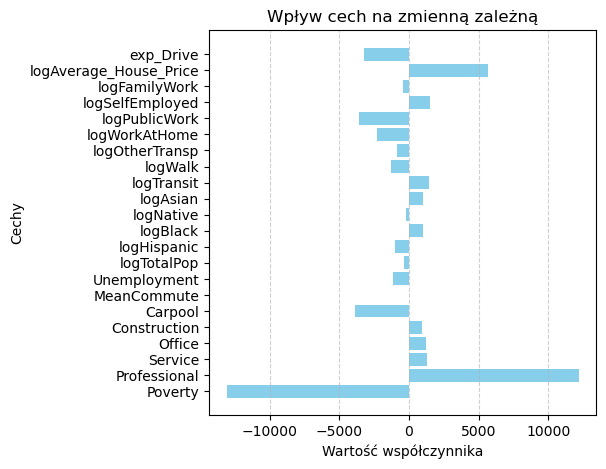

In [20]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, df['IncomePerCap'], test_size=0.2, random_state=42)

X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

e_train1, e_test1, r2_train1, r2_test1, coefs1 = linear_regression(X_train1, X_test1, y_train1, y_test1)
print('Mean Squared Error for train:', e_train1)
print('Mean Squared Error for test:', e_test1)
print('R2 Score for train:', r2_train1)
print('R2 Score for test:', r2_test1)
print('Coefficients:', coefs1)

plt.figure(figsize=(5, 5))
plt.barh(X1.columns.values, coefs1, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


Dla cech dobranych metodą zachłanną (krokową w przód):

In [21]:
y = df['IncomePerCap']
x = df[best_features]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
features = x_train.columns.values
features

array(['Poverty', 'Professional', 'logAverage_House_Price',
       'logPublicWork', 'logTransit', 'Carpool', 'Unemployment',
       'logFamilyWork', 'logSelfEmployed', 'logAsian', 'logBlack',
       'logOtherTransp', 'Office', 'logTotalPop'], dtype=object)

Używamy standaryzacji danych, aby bezpośrednio porównać, który z atrybutów opisujących ma największy wpływ na atrybut decyzyjny.

In [22]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

/tmp/ipykernel_84168/2690550006.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
/tmp/ipykernel_84168/2690550006.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


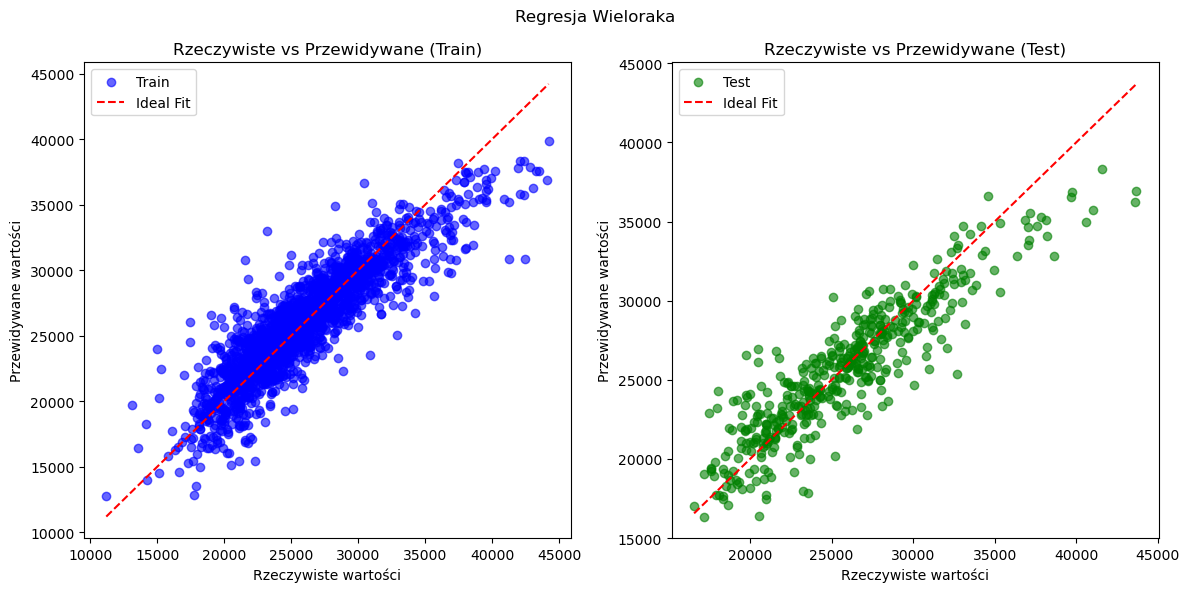

Mean Squared Error for train: 4706006.362868563
Mean Squared Error for test: 4517430.231263008
R2 Score for train: 0.7979199006213347
R2 Score for test: 0.8106983070412483
Coefficients: [-2095.88110166  1740.28273288   951.74682788  -538.43331045
   404.88295724  -324.91887765  -174.30669971  -110.08799519
   228.91827731   191.57606584   242.76604792   -26.12355171
   165.07237576  -169.33033023]


In [23]:
e_train, e_test, r2_train, r2_test, coefs = linear_regression(x_train, x_test, y_train, y_test)
print('Mean Squared Error for train:', e_train)
print('Mean Squared Error for test:', e_test)
print('R2 Score for train:', r2_train)
print('R2 Score for test:', r2_test)
print('Coefficients:', coefs)

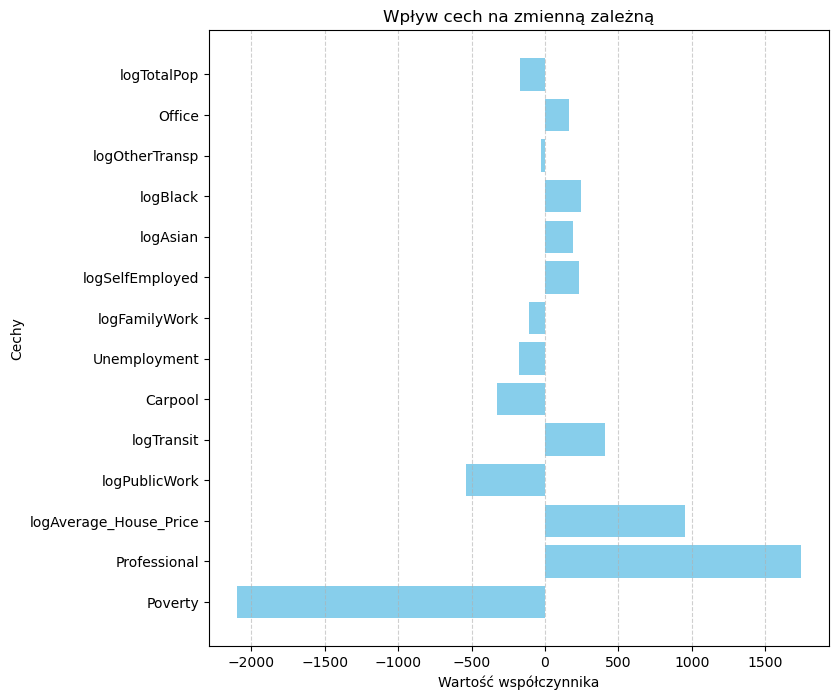

In [24]:
plt.figure(figsize=(8, 8))
plt.barh(best_features, coefs, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Zgodnie z postawioną hipotezą współczynnik ubóstwa, wykształcenie i średnia cena nieruchomości mają największy wpływ na średni dochód w danym hrabstwie. Jendakże zawiedliśmy się, ponieważ zróżnicowanie rasowe miało, ale zdecydowanie mniejsze znaczenie niż wcześniej wspomniane współczynniki. Podobna sytuacja jest z bezrobociem, które nie ma wysokiej wartości współczynnika.

### Regularyzacja

Funkcję do wykonania doboru współczynnika 'alpha', dla regularyzacji Ridge i Lasso.

In [25]:
def ridge_regression(X_train, X_test, y_train, y_test, alpha):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred_train = ridge.predict(X_train)
    y_pred_test = ridge.predict(X_test)
    e_train = mean_squared_error(y_train, y_pred_train)
    e_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle("Regresja Ridge")
    axs[0].scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
    axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
    axs[0].set_xlabel("Rzeczywiste wartości")
    axs[0].set_ylabel("Przewidywane wartości")
    axs[0].set_title("Rzeczywiste vs Przewidywane (Train)")
    axs[0].legend()

    axs[1].scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
    axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
    axs[1].set_xlabel("Rzeczywiste wartości")
    axs[1].set_ylabel("Przewidywane wartości")
    axs[1].set_title("Rzeczywiste vs Przewidywane (Test)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    return e_train, e_test, r2_train, r2_test, ridge.coef_

In [26]:
def lasso_regression(X_train, X_test, y_train, y_test, alpha):
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    y_pred_train = lasso.predict(X_train)
    y_pred_test = lasso.predict(X_test)
    e_train = mean_squared_error(y_train, y_pred_train)
    e_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle("Regresja Ridge")
    axs[0].scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
    axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
    axs[0].set_xlabel("Rzeczywiste wartości")
    axs[0].set_ylabel("Przewidywane wartości")
    axs[0].set_title("Rzeczywiste vs Przewidywane (Train)")
    axs[0].legend()

    axs[1].scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
    axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
    axs[1].set_xlabel("Rzeczywiste wartości")
    axs[1].set_ylabel("Przewidywane wartości")
    axs[1].set_title("Rzeczywiste vs Przewidywane (Test)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    return e_train, e_test, r2_train, r2_test, lasso.coef_

In [27]:
df.iloc[:, 3:]

,IncomePerCap,Poverty,Professional,Service,Office,Construction,Carpool,MeanCommute,Unemployment,logTotalPop,...,logAsian,logTransit,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_Drive
0,27824,13.7,35.3,18.0,23.2,8.1,9.6,25.8,5.2,6.403152,...,0.000000,-1.070050,-0.190552,0.187789,2.356581,2.740385,1.584241,-3.969362,6.707548,5.099342e+08
1,29364,11.8,35.7,18.2,25.6,9.7,7.6,27.0,5.5,7.169821,...,-0.550340,-1.070050,-0.056288,0.101756,4.292518,2.334718,1.689675,-3.969362,6.866816,4.761912e+08
2,17561,27.2,25.0,16.8,22.6,11.5,11.1,23.4,12.4,5.967797,...,-0.879669,-0.609205,0.444977,0.328050,0.829843,2.689675,1.717685,-2.259851,6.440511,4.442108e+08
3,20911,15.2,24.4,17.6,19.7,15.9,9.5,30.0,8.2,5.880555,...,-5.678874,-0.148359,-0.489523,0.328050,1.159172,2.605288,1.689675,-2.259851,6.597469,5.206819e+08
4,22021,15.6,28.5,12.9,23.3,15.8,10.2,35.0,4.9,6.430544,...,-3.969362,-1.070050,-0.370310,-0.386853,1.944575,2.261860,1.284336,-3.969362,6.651177,5.316049e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,31643,6.8,41.1,17.5,20.2,12.1,10.9,16.0,3.1,6.046515,...,-0.550340,-0.800473,0.653795,-0.124539,4.292518,2.821826,1.689675,-2.969362,6.962623,3.561657e+08
2323,31700,12.0,27.7,16.1,20.0,20.8,14.4,20.5,5.2,6.278859,...,-0.879669,0.660373,0.568816,0.187789,1.159172,2.625859,1.238814,-5.678874,6.854041,3.194315e+08
2324,27115,14.9,30.4,19.4,18.1,16.1,14.9,19.9,6.4,5.831205,...,-3.969362,0.813639,0.097404,0.187789,1.829843,2.796886,1.731373,-1.709511,6.773738,3.175833e+08
2325,27345,12.8,32.1,16.3,17.6,18.8,10.2,14.3,6.1,5.290197,...,-3.969362,-1.530895,1.039592,0.187789,3.709511,2.817716,1.915265,-2.969362,6.712298,3.139119e+08


In [46]:
from sklearn.model_selection import cross_validate
import matplotlib.gridspec as gridspec

def ridge_find_alpha(x, y):
    parameters = [0.01 * 2**i for i in range(11)]
    parameters.insert(0, 0)
    train_scores = []
    test_scores = []
    ws = []

    for lamb in parameters:
        result = cross_validate(Ridge(alpha = lamb, fit_intercept=True), x, y, return_train_score = True, cv = 5, scoring = 'neg_mean_squared_error', return_estimator = True)
        train_scores.append(np.mean(-result['train_score']))
        test_scores.append(np.mean(-result['test_score']))
        best_model: Ridge = result['estimator'][np.argmax(result['test_score'])]
        coefficients = best_model.coef_
        coefficients[0] = best_model.intercept_
        ws.append(coefficients.flatten().tolist())

    print(train_scores)
    print(test_scores)
    best_lambda = parameters[np.argmin(test_scores)]
    print('Best lambda:', best_lambda)
    gs = gridspec.GridSpec(2, 2)
    fig = plt.figure(figsize=(12,8))

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(parameters, train_scores, '*-')
    plt.yscale('log')
    plt.xscale('log')
    plt.title('Średni błąd uczenia dla różnych wartości lambda')

    print(np.argmin(test_scores))
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(parameters, test_scores, '*-', color='red')
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Średni błąd walidacji dla różnych wartości lambda')

    ax3 = fig.add_subplot(gs[1, :])
    for i in range(len(best_features)):
        ax3.plot(parameters, [w[i] for w in ws])
    plt.legend([f'$w_{{{i}}}$' for i in range(len(best_features))], loc='lower right')
    plt.yscale('log')
    plt.xscale('log')
    plt.title('Współczynniki dla kolejnych wartości lambda')

    return best_lambda



[4946163.9949148465, 4946163.995150514, 4946163.995857503, 4946163.998685361, 4946164.009995998, 4946164.055232183, 4946164.236126062, 4946164.95929504, 4946167.848724248, 4946179.380556984, 4946225.302236459, 4946407.366122803]
[5058528.414963515, 5058528.041849715, 5058527.669248459, 5058526.925583481, 5058525.444402983, 5058522.506634357, 5058516.7294229735, 5058505.567955086, 5058484.814056015, 5058449.5602347525, 5058403.892610494, 5058410.533437343]
Best lambda: 5.12
10
5.12


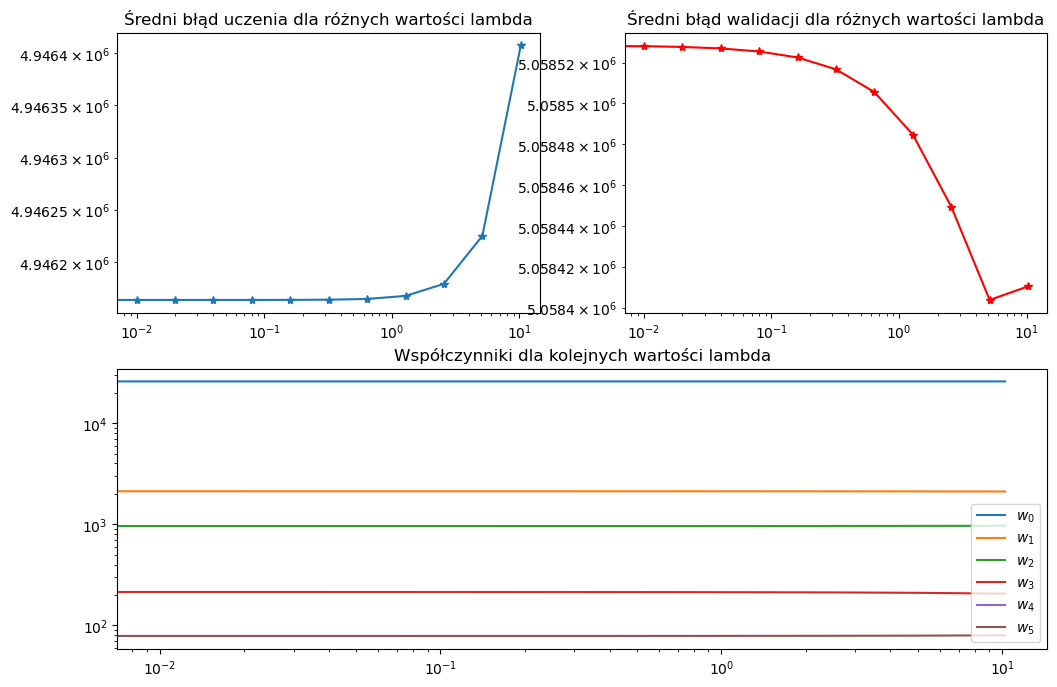

In [47]:
x= scaler.fit_transform(x)
ridge_best_alpha = ridge_find_alpha(x, y)
print(ridge_best_alpha)

/tmp/ipykernel_84168/465976509.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
/tmp/ipykernel_84168/465976509.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


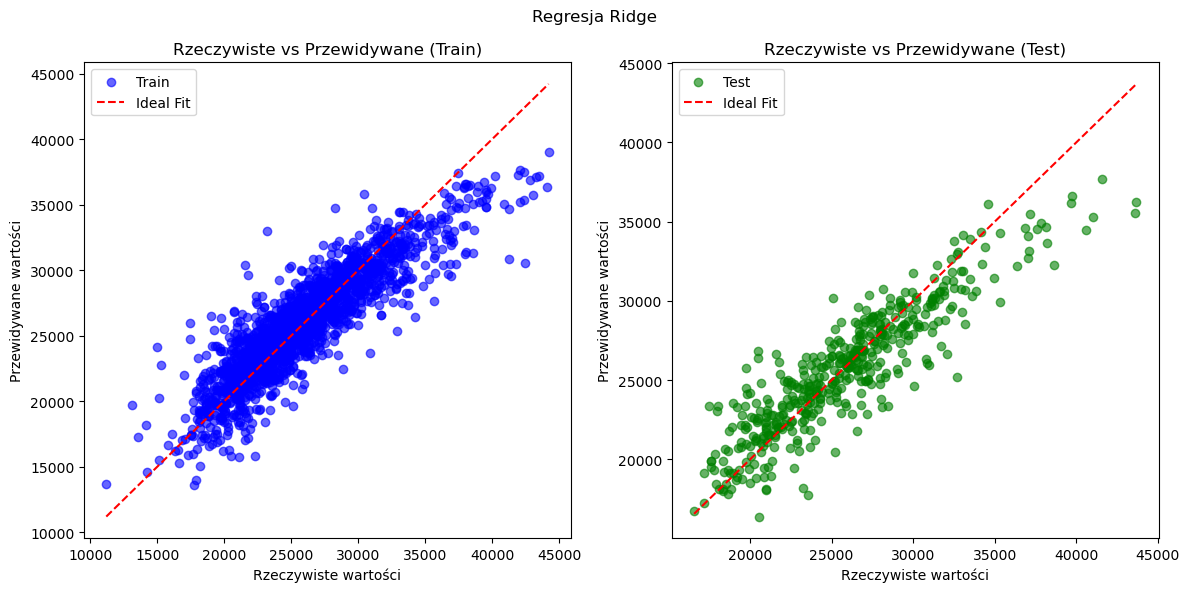

Mean Squared Error for train: 4778902.847976326
Mean Squared Error for test: 4751850.17471306
R2 Score for train: 0.7947896607068368
R2 Score for test: 0.8008750026653924
Coefficients: [-1.11661943e+04  9.69260439e+03  2.27292241e+01  9.33906859e+02
 -8.15315526e+00 -2.52006967e+03  1.90059392e+02 -2.27091626e+03
  3.48632392e+02 -6.97764788e+02  5.57312402e+02 -3.59646481e+02
  1.25643607e+03  1.71789438e+03 -7.56529784e+01 -3.33944848e+02
  4.89213080e+02 -2.33296089e+03  1.25723260e+03 -4.37167241e+02
  5.84886270e+03 -6.44818067e+02]


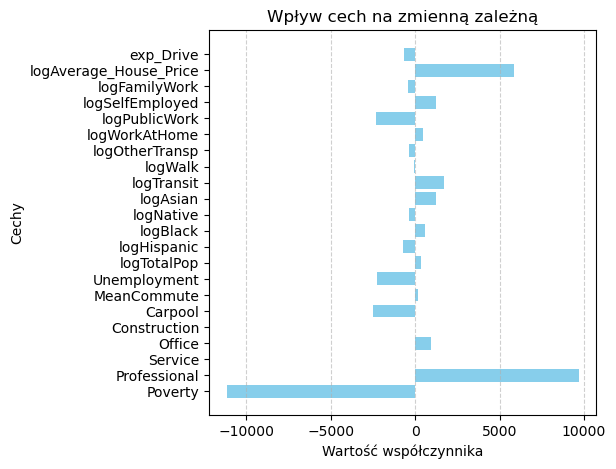

In [48]:
e_train2, e_test2, r2_train2, r2_test2, coefs2 = ridge_regression(X_train1, X_test1, y_train1, y_test1, ridge_best_alpha)
print('Mean Squared Error for train:', e_train2)
print('Mean Squared Error for test:', e_test2)
print('R2 Score for train:', r2_train2)
print('R2 Score for test:', r2_test2)
print('Coefficients:', coefs2)

plt.figure(figsize=(5, 5))
plt.barh(X1.columns.values, coefs2, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_84168/465976509.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
/tmp/ipykernel_84168/465976509.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


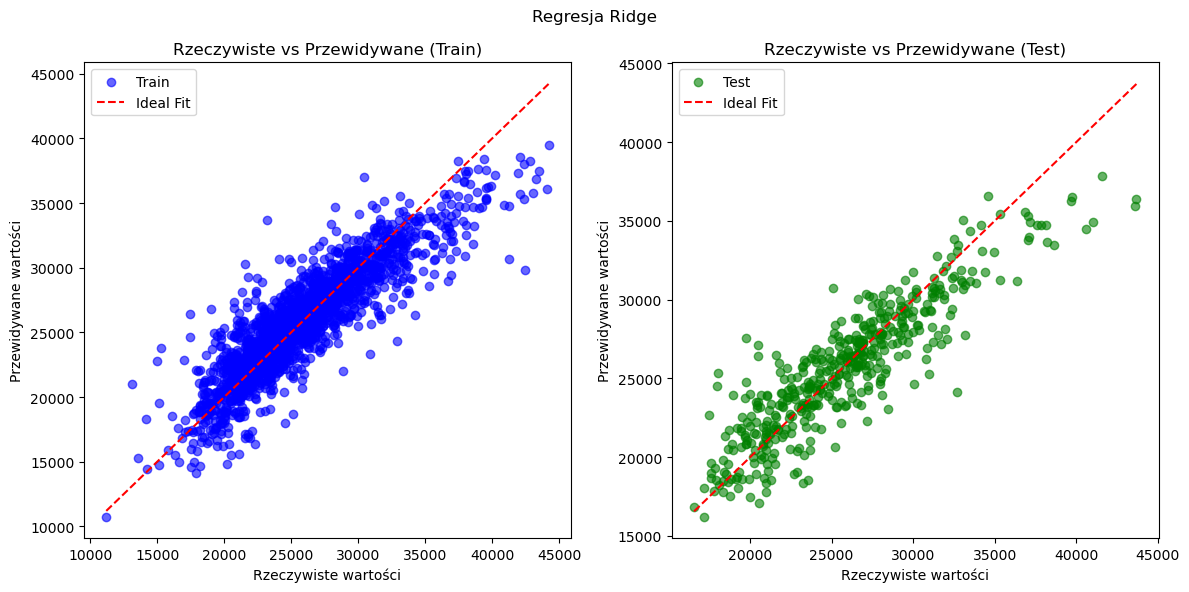

Mean Squared Error for train: 4990844.097643248
Mean Squared Error for test: 4872523.673572385
R2 Score for train: 0.7856887149169922
R2 Score for test: 0.7958182123089558
Coefficients: [ -419.91767404   385.63453788  3754.63287834    66.61175732
 -2436.25537452    73.41054517]


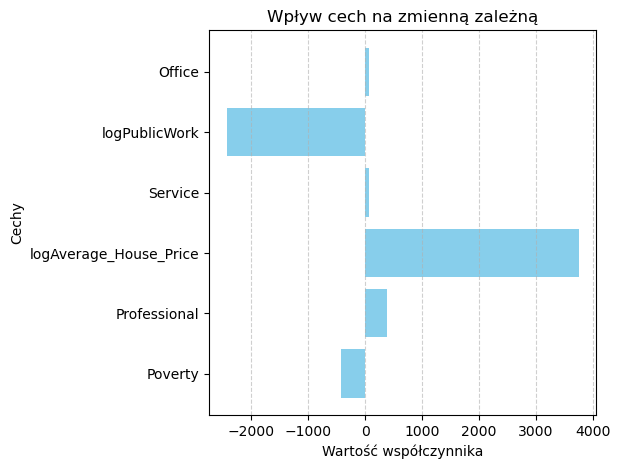

In [49]:
e_train3, e_test3, r2_train3, r2_test3, coefs3 = ridge_regression(x_train, x_test, y_train, y_test, ridge_best_alpha)
print('Mean Squared Error for train:', e_train3)
print('Mean Squared Error for test:', e_test3)
print('R2 Score for train:', r2_train3)
print('R2 Score for test:', r2_test3)
print('Coefficients:', coefs3)


plt.figure(figsize=(5, 5))
plt.barh(best_features, coefs3, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


In [51]:
from sklearn.model_selection import cross_validate
import matplotlib.gridspec as gridspec
from math import sqrt
import numpy as np
from matplotlib import pyplot as plt

def lasso_find_alpha(x, y):
    parameters = [0.01 * 2**i for i in range(20)]
    parameters.insert(0, 0)
    train_scores = []
    test_scores = []
    ws = []

    for lamb in parameters:
        result = cross_validate(Lasso(alpha = lamb), scaler.fit_transform(x), y, return_train_score = True, cv = 5, scoring = 'neg_mean_squared_error', return_estimator = True)
        train_scores.append(sqrt(np.mean(-result['train_score'])))
        test_scores.append(sqrt(np.mean(-result['test_score'])))
        best_model: Lasso = result['estimator'][np.argmax(result['test_score'])]
        coefficients = best_model.coef_
        ws.append(coefficients.flatten().tolist())

    print(train_scores)
    print(test_scores)
    best_lambda = parameters[np.argmin(test_scores)]
    print('Best lambda:', best_lambda)
    gs = gridspec.GridSpec(2, 2)
    fig = plt.figure(figsize=(12,8))

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(parameters, train_scores)
    plt.title('Średni błąd uczenia dla różnych wartości lambda')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(parameters, test_scores, '*-', color='red')
    # plt.yscale('log')
    plt.title('Średni błąd walidacji dla różnych wartości lambda')

    ax3 = fig.add_subplot(gs[1, :])
    for i in range(len(best_features)):
        ax3.plot(parameters, [w[i] for w in ws])
    plt.legend([f'$w_{{{i}}}$' for i in range(len(best_features))], loc='lower right')
    plt.title('Współczynniki dla kolejnych wartości lambda')

    return best_lambda

/usr/lib/python3/dist-packages/sklearn/base.py:1474: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/lib/python3/dist-packages/sklearn/linear_model/_coordinate_descent.py:678: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/lib/python3/dist-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.277e+09, tolerance: 4.092e+06 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/lib/python3/dist-pac

[2223.997301013391, 2223.9973011428824, 2223.997301531937, 2223.997303083921, 2223.9973093018925, 2223.997334153187, 2223.9974334283766, 2223.9978306943467, 2223.9994187396333, 2224.0057576354934, 2224.0311314721507, 2224.132595968025, 2224.538387781084, 2226.1608995239226, 2231.675843345242, 2245.1603237934805, 2289.5168876204516, 2439.197054957903, 2825.789662111676, 3968.082085483415, 4834.932485968136]
[2249.1172523822574, 2249.117239261246, 2249.1172167257305, 2249.1171938955754, 2249.1171353900254, 2249.1169586507035, 2249.116865689481, 2249.1166855309843, 2249.117145804782, 2249.1223120384084, 2249.1445472518117, 2249.2428423989913, 2249.65197112441, 2251.3187488881194, 2255.5348773365104, 2266.3805747760953, 2309.221044526958, 2456.5101189561906, 2848.656071919405, 4005.9730536482225, 4863.536355019892]
Best lambda: 0.64
0.64


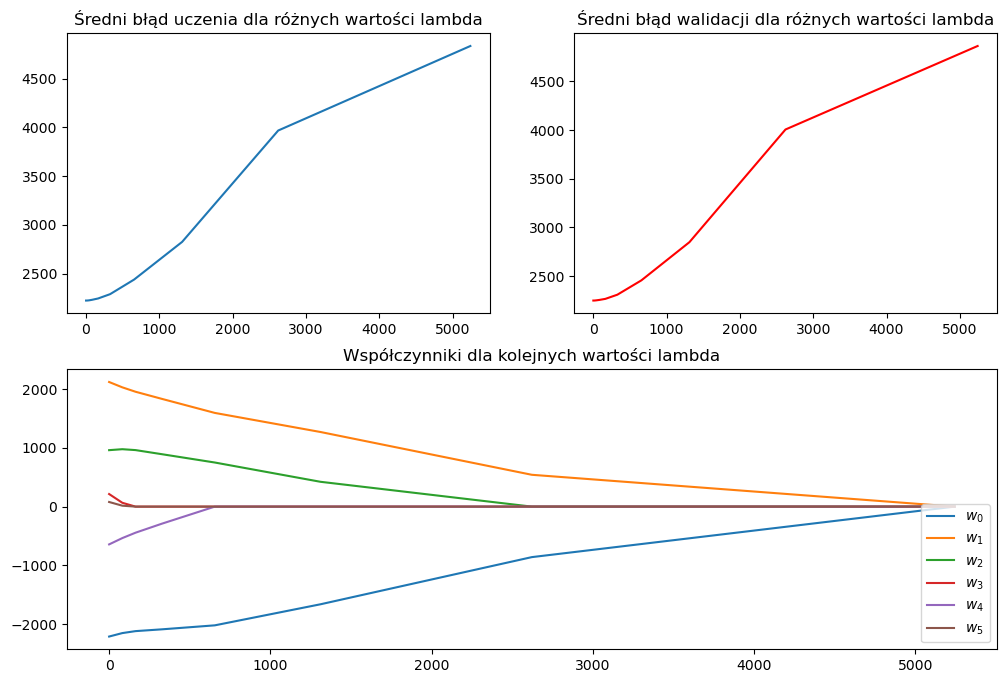

In [52]:
lasso_best_alpha = lasso_find_alpha(x, y)
print(lasso_best_alpha)

/tmp/ipykernel_84168/1473633239.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
/tmp/ipykernel_84168/1473633239.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


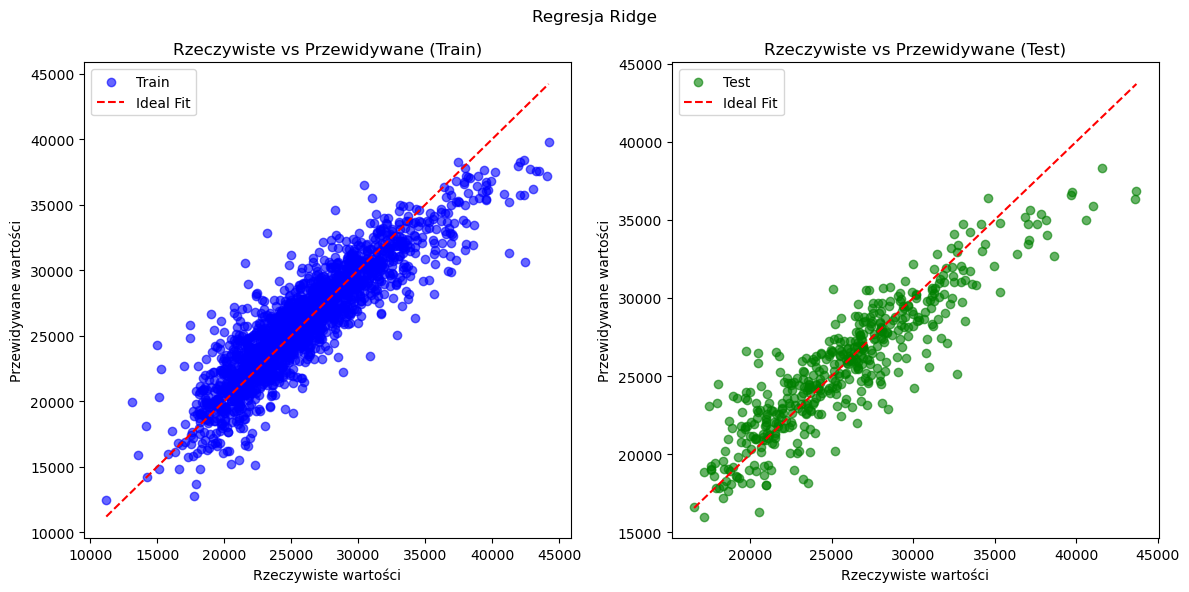

Mean Squared Error for train: 4646842.337675787
Mean Squared Error for test: 4507821.818530833
R2 Score for train: 0.80046045649158
R2 Score for test: 0.811100944980017
Coefficients: [-13027.71712091  12108.04636539   1185.5703227    1160.74411447
    872.35144084  -3257.63823897      0.          -1182.55515897
   -325.37359925   -921.77584218   1003.61851242   -252.11768298
    972.11054552   1554.63078401   -832.72593712   -594.59853303
  -1578.9952754   -3426.89797713   1485.90205445   -417.53103463
   5650.22211094  -2153.86477236]


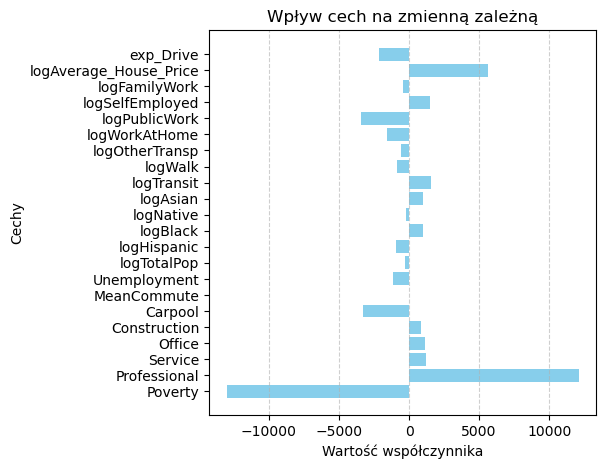

In [53]:
e_train4, e_test4, r2_train4, r2_test4, coefs4 = lasso_regression(X_train1, X_test1, y_train1, y_test1, lasso_best_alpha)
print('Mean Squared Error for train:', e_train4)
print('Mean Squared Error for test:', e_test4)
print('R2 Score for train:', r2_train4)
print('R2 Score for test:', r2_test4)
print('Coefficients:', coefs4)

plt.figure(figsize=(5, 5))
plt.barh(X1.columns.values, coefs4, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_84168/1473633239.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
/tmp/ipykernel_84168/1473633239.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


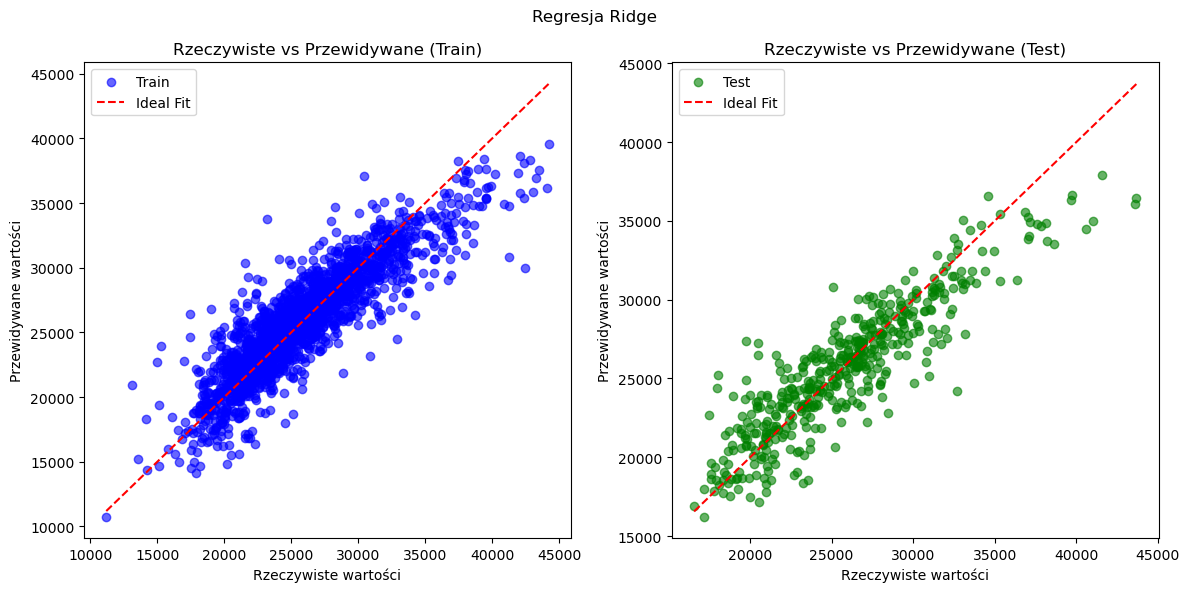

Mean Squared Error for train: 4987045.438081548
Mean Squared Error for test: 4864874.70674108
R2 Score for train: 0.785851832737612
R2 Score for test: 0.7961387401968091
Coefficients: [ -413.78462163   382.76406819  4046.01712698    64.10320543
 -2521.418654      67.36467251]


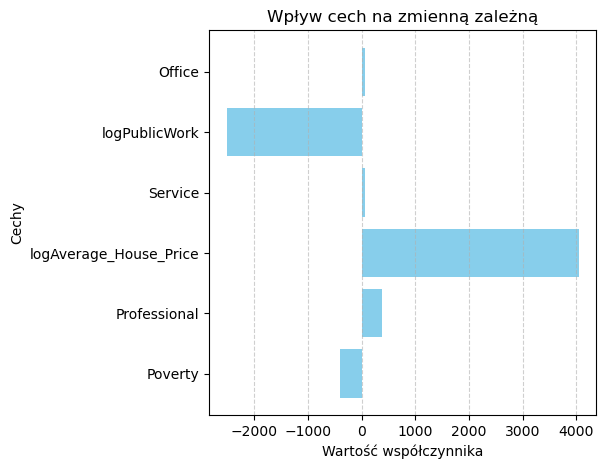

In [54]:
e_train5, e_test5, r2_train5, r2_test5, coefs5 = lasso_regression(x_train, x_test, y_train, y_test, lasso_best_alpha)
print('Mean Squared Error for train:', e_train5)
print('Mean Squared Error for test:', e_test5)
print('R2 Score for train:', r2_train5)
print('R2 Score for test:', r2_test5)
print('Coefficients:', coefs5)

plt.figure(figsize=(5, 5))
plt.barh(best_features, coefs5, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


### Inne modele regresji

Regresja z użyciem drzewa decyzyjnego

In [55]:
from scripts.greedy_features_tree import find_best_features

features = df.columns[3:]
find_best_features(df[features], 'IncomePerCap')

['Poverty'] 11320833.812096845

['Poverty', 'Professional'] 12866147.06488809

['Poverty', 'Professional', 'logAverage_House_Price'] 10493245.085586783

['Poverty', 'Professional', 'logAverage_House_Price', 'Service'] 9394963.361760119

['Poverty', 'Professional', 'logAverage_House_Price', 'Service', 'logPublicWork'] 8977029.691955328

['Poverty', 'Professional', 'logAverage_House_Price', 'Service', 'logPublicWork', 'Office'] 8849507.705981817

['Poverty', 'Professional', 'logAverage_House_Price', 'Service', 'logPublicWork', 'Office', 'MeanCommute'] 8978482.760873137

['Poverty', 'Professional', 'logAverage_House_Price', 'Service', 'logPublicWork', 'Office', 'MeanCommute', 'Carpool'] 9127295.900572246

['Poverty', 'Professional', 'logAverage_House_Price', 'Service', 'logPublicWork', 'Office', 'MeanCommute', 'Carpool', 'logTotalPop'] 9200356.016716968

['Poverty', 'Professional', 'logAverage_House_Price', 'Service', 'logPublicWork', 'Office', 'MeanCommute', 'Carpool', 'logTotalPop', 'lo

In [56]:
best_features = ['Poverty', 'Professional', 'logAverage_House_Price', 'Service', 'logPublicWork', 'Office']

In [57]:
from sklearn.metrics import mean_squared_error

def verify(model, x_train, x_test, y_train, y_test, train_err, test_err):
    y_train_res = model.predict(x_train)
    y_test_res = model.predict(x_test)
    train_err.append(mean_squared_error(y_train_res, y_train))
    test_err.append(mean_squared_error(y_test_res, y_test))

def plot_results(x, train_err, test_err, title, x_label):
    plt.figure(dpi=100)
    plt.title(title)
    plt.plot(x, train_err, 'bo-', label = 'dane uczące')
    plt.xlabel(x_label)
    plt.ylabel('Błąd')
    plt.plot(x, test_err, 'ro-', label = 'dane testowe')
    plt.legend(loc='center right')
    plt.show()

Dane dla maksymalnej głębokości 1
glebokosc drzewa decyzyjnego: 1 dla max glebokosci: 1


Dane dla maksymalnej głębokości 2
glebokosc drzewa decyzyjnego: 2 dla max glebokosci: 2


Dane dla maksymalnej głębokości 3
glebokosc drzewa decyzyjnego: 3 dla max glebokosci: 3


Dane dla maksymalnej głębokości 5
glebokosc drzewa decyzyjnego: 5 dla max glebokosci: 5


Dane dla maksymalnej głębokości 7
glebokosc drzewa decyzyjnego: 7 dla max glebokosci: 7


Dane dla maksymalnej głębokości 8
glebokosc drzewa decyzyjnego: 8 dla max glebokosci: 8


Dane dla maksymalnej głębokości 10
glebokosc drzewa decyzyjnego: 10 dla max glebokosci: 10


Dane dla maksymalnej głębokości 12
glebokosc drzewa decyzyjnego: 12 dla max glebokosci: 12


Dane dla maksymalnej głębokości 15
glebokosc drzewa decyzyjnego: 15 dla max glebokosci: 15


Dane dla maksymalnej głębokości 16
glebokosc drzewa decyzyjnego: 16 dla max glebokosci: 16


Dane dla maksymalnej głębokości 18
glebokosc drzewa decyzyjnego: 18 dla max glebokosci: 

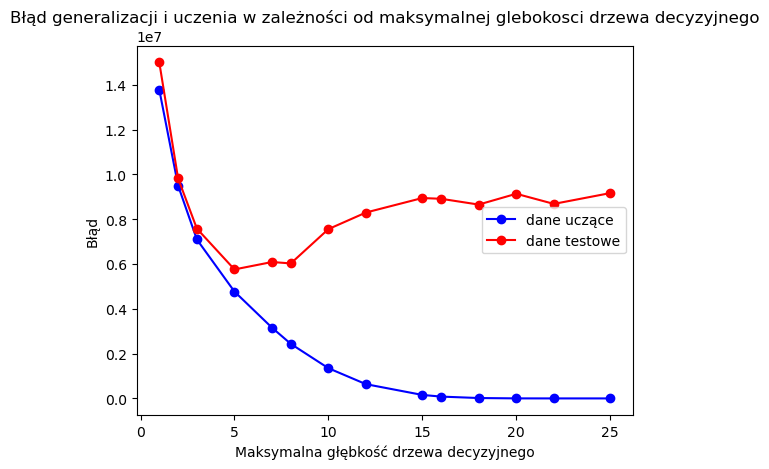

Minimalny błąd generalizacji: 5757128.415377565 dla maksymalnej głębokości: 5
Błąd uczenia dla tej głębokości: 4769505.027527909


In [58]:
from sklearn.tree import DecisionTreeRegressor

depths = [1, 2, 3, 5, 7, 8, 10, 12, 15, 16, 18, 20, 22, 25]
train_err = []
test_err =[]
x = df[best_features]
y = df['IncomePerCap']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

for i, g in enumerate(depths):
    model = DecisionTreeRegressor(max_depth = g, random_state=42)
    model.fit(x_train, y_train)
    print('Dane dla maksymalnej głębokości', g)
    verify(model, x_train, x_test, y_train, y_test, train_err, test_err)
    print('glebokosc drzewa decyzyjnego:', model.get_depth(), 'dla max glebokosci:', g)
    print('\n')
title = 'Błąd generalizacji i uczenia w zależności od maksymalnej glebokosci drzewa decyzyjnego'
x_label = 'Maksymalna głębkość drzewa decyzyjnego'
plot_results(depths, train_err, test_err, title, x_label)
print('Minimalny błąd generalizacji:', min(test_err), 'dla maksymalnej głębokości:', depths[test_err.index(min(test_err))])
print('Błąd uczenia dla tej głębokości:', train_err[test_err.index(min(test_err))])

Błąd generalizacji wraz ze wzrostem głębokości drzewa spada praktycznie do zera, co jest charakterystyczne dla drzew decyzyjnych, które przy dużych głębokościach zaczynają się dopasowywać do danych uczących.

Z tego powodu należy wybrać głębokość, dla której zachowywana jest zdolność generalizacji, czyli w naszym przypadku głębokość równa 5.

Sam wynik uczenia nie jest lepszy niż dla regresji liniowej.

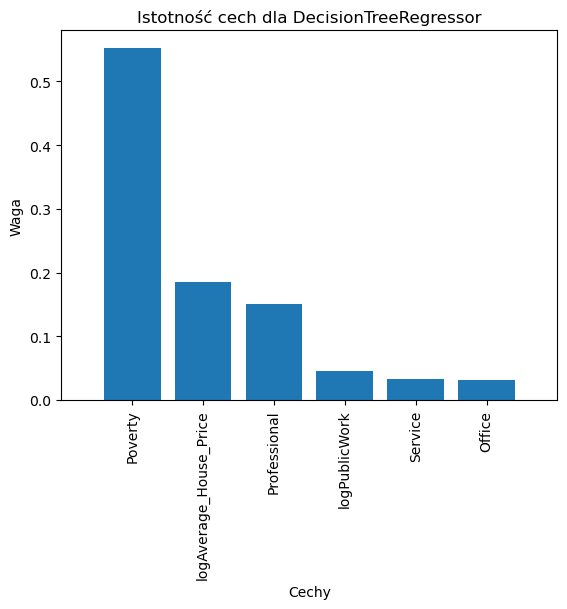

In [59]:
def plot_feature_importances(model, feature_names, title):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(dpi=100)
    plt.title(title)
    plt.bar(range(x.shape[1]), importances[indices], align="center")
    plt.xticks(range(x.shape[1]), [feature_names[i] for i in indices], rotation=90)
    plt.xlim([-1, x.shape[1]])
    plt.xlabel('Cechy')
    plt.ylabel('Waga')
    plt.show()

plot_feature_importances(model, best_features, "Istotność cech dla DecisionTreeRegressor")

##### AdaBoostRegressor

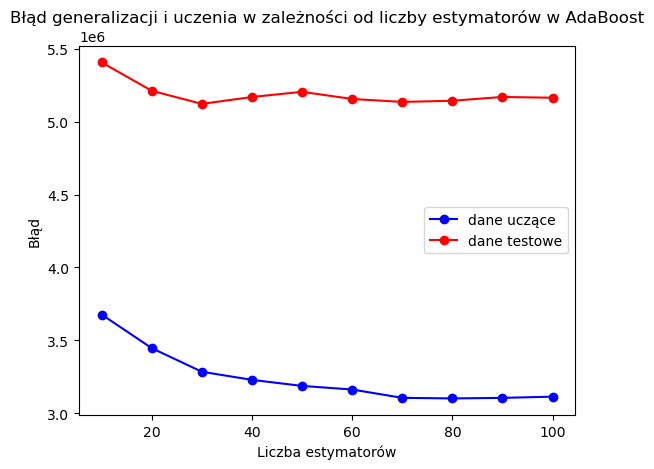

Minimalny błąd generalizacji: 5122049.462576979 dla liczby estymatorów: 30
Błąd uczenia dla tej liczby estymatorów: 3284056.2804035433


In [60]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

n_estimators = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

train_err = []
test_err = []

best_tree = DecisionTreeRegressor(max_depth=5, random_state=42)

for i, n in enumerate(n_estimators):
    model = AdaBoostRegressor(estimator=best_tree, n_estimators=n, random_state=42)
    model.fit(x_train, y_train)
    verify(model, x_train, x_test, y_train, y_test, train_err, test_err)

title = 'Błąd generalizacji i uczenia w zależności od liczby estymatorów w AdaBoost'
x_label = 'Liczba estymatorów'
plot_results(n_estimators, train_err, test_err, title, x_label)

print(f'Minimalny błąd generalizacji: {min(test_err)} dla liczby estymatorów: {n_estimators[test_err.index(min(test_err))]}')
print(f'Błąd uczenia dla tej liczby estymatorów: {train_err[test_err.index(min(test_err))]}')

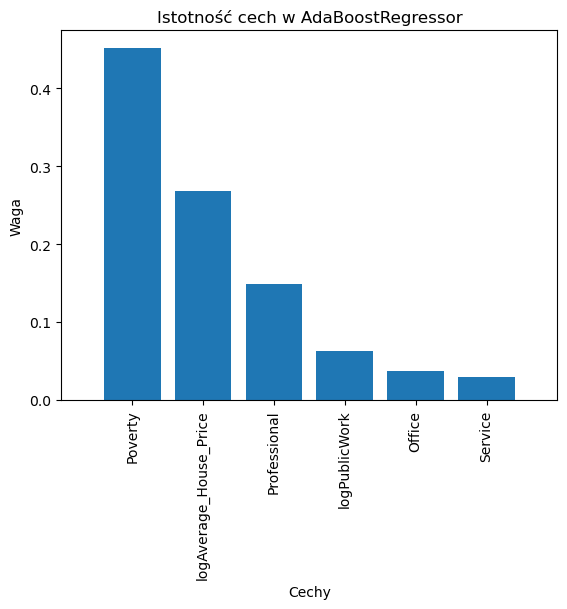

In [61]:
model = AdaBoostRegressor(estimator = DecisionTreeRegressor(max_depth=5), n_estimators=20, random_state=42)
model.fit(x_train, y_train)
plot_feature_importances(model, best_features, "Istotność cech w AdaBoostRegressor")

Boosting zmniejszył istotność atrybutu `Poverty` na rzecz pozostałych w kolejności atrybutów.

Sam Boosting mocno zmniejszył błąd uczenia, przy okazji trochę zmniejszając błąd generalizacji, jednakże nadal nie jest on lepszy od modelu z użyciem regularyzacji.

### Podsumowanie rezultatów modeli

Błąd średniokwadratowy
| Model                   | Dane uczące | Dane testowe |
| :---------------- | ------: | ----: |
| Regresja Liniowa        |   4644371.217234767   | 4517430.231263008 |
| Regresja Grzbietowa           |   0,0  | 0,0 |
| Regresja Lasso           |   0,59  | 0,61 |
| Regresor Drzewa Decyzyjnego           |   4769505.027527909  | 5757128.415377565 |
| Regresor AdaBoost           |   3284056.2804035433  | 5122049.462576979 |

### Raport

Praca nad analizą naszego zbioru i budowaniem modelu przebiegała następująco:

W I etapie:
Wybraliśmy do analizy zbiór danych CENSUS (https://www.kaggle.com/datasets/muonneutrino/us-census-demographic-data). Określiliśmy cel naszej analizy: Predykcja dochodu na mieszkańca w zależności od danych demograficznych i ekonomicznych w Stanach Zjednoczonych w 2017 roku (na poziomie hrabstw).

W II etapie:
1) Przedstawiliśmy podstawowe statystyki danych oraz połączyliśmy wybrany zbiór danych ze zbiorem danych z Zillow (https://www.zillow.com/), na podstawie nazwy stanu i hrabstwa, dla odpowiedniego roku. Dodaliśmy w ten sposób kolejny atrybut o dużej istotności dla rozważanego zbioru, czyli średnią wartość nieruchomości. Przez braki danych w zbiorze z Zillow ilość rekordów spadła z 3219 do 2894.
2) Na podstawie wykresów pudełkowych, histogramów i rozszerzonych podstawowych statystyk danych (średnia, mediana, moda) określiliśmy, które ze zmiennych są lewo, bądź prawoskośne.
3) Określiliśmy korelację między atrybutami opisującymi, wskazując te atrybuty, które są mocno/bardzo słabo skorelowane z atrybutem decyzyjnym oraz te atrybuty opisujące, które mają wysoką korelację między sobą i są zbędne. Te atrubuty, to: `Men`, `Women`, `VotingAgeCitizen`, `Employed`, `ChildPoverty`, `Income`, `IncomeErr`, `IncomePerCapErr`. Usunęliśmy również atrybut `CountyId`, ponieważ po analizie zdecydowaliśmy, że jedynym jego znaczenie było indeksowanie danych.
4) Usunęliśmy wartości odstające z danych, stosując miarę odległości od średniej wartości jako 3 odchylenia standardowe, co zmniejszyło liczbę rekordów z 2894 do 2327. Zdecydowaliśmy się na taką miarę, ponieważ inna znana metoda - IQR, czyli odległość 1,5 wartości odchylenia standardowego, pozostawiała jedynie ok. 600 rekordów.
5) Po otrzymaniu zbioru gotowego do doboru cech i trenowania modelu regresji sprawdziliśmy ponownie podstawowe statystki danych, korelację i rozkłady zmiennych. Zweryfikowaliśmy w ten sposób, że atrybuty opisujące mają rozkład bardziej zbliżony do normalnego.
6) Wykonaliśmy wizualizacje w postaci naniesienia informacji o liczbie ludności oraz dochodzie na mieszkańca i usuniętych hrabstwach na mapę Stanów Zjednoczonych.
7) Postawiliśmy hipotezę badawczą, w której określiliśmy, że największy wpływ na atrybut decyzyjny będą miały: ceny nieruchomości, zróżnicowanie rasowe, sektor gospodarki oraz wskaźnik ubóstwa w regionie.

W III etapie:
1) Dokonaliśmy transformacji wcześniej wspomnianych atrybutów, z rozkładu lewo/prawo skośnego do rozkładu bardziej przypominającego normalny na podstawie wyników testu Shapiro-Wilka. Zastosowaliśmy dobór logarytmu o najlepszej podstawie dla danych prawoskośnych i dobór najlepszego wykładnika dla danych lewoskośnych.
2) Przeanalizowaliśmy wzajemne korelacje atrybutów opisujących. W przypadku par silnie skorelowanych (np. procent osób pracujących w sektorze publicznym/prywatnym) wykluczyliśmy tą z pary, która mniej skorelowana jest z atrybutem decyzyjnym.
3) Dobraliśmy metodą zachłanną podzbiór cech do modelu regresji. Proces przeprowadziliśmy dla danych przeskalowanych, zregularyzowanych i niezmodyfikowanych.Zaobserwowaliśmy, że w tym przypadku transformacja zbioru przed doborem ma nieznaczny wpływ na wynik. Wybrany podzbiór miał 13 cech, prawie dwa razy mniej od oryginalnego.
4) Stworzyliśmy model regresji wielorakiej. Porównaliśmy wyniki dla całego zbioru i dla wybranego metodą zachłanną podzbioru. Potwierdziliśmy, że mimo dwukrotnie mniejszej ilości cech udało się otrzymać model prawie równie dobrej jakości.
5) Stworzyliśmy model regresji grzbietowej i Lasso, badając wpływ parametru alfa na zachowanie modelu.
6) Stworzyliśmy model regresji z użyciem drzewa decyzyjnego. Dobraliśmy zestaw cech metodą zachłanną, otrzymując zbiór 6 parametrów. Zbadaliśmy wpływ głębokości drzewa na jakość modelu. Model nie okazał się być nieco gorszy od modeli poprzednich. Najlepszą głębokością drzewa okazała się głębokość 5. Dla tej głębokości wypróbowaliśmy następnie metodę z użyciem AdaBoost, przeprowadzając test dla różnych ilości estymatorów. Metoda ta nie wykazała się lepszą skutecznością. 